# Reflection and Emitting Surfaces

This tutorial covers how to make forward model emission (+reflection) spectra for a terrestrial exoplanet with a reflective and emitting surface.

We both demonstrate how to generate models for rocky exoplanets with overlaying atmospheres, and rocky exoplanets without atmospheres. 

## Surfaces are Important 

PUT FIGURE FROM PAPER HERE

## Reflecting and Emitting Surfaces - Rocky Exoplanets w/ Overlaying Atmospheres (TRAPPIST-1e)

Here, we build off the transmission_terrestrial tutorial by defining Trappist-1e with a reflecting and emitting surface. 

We will explore a wavelength range that explores short wavelengths (0.3-1 um) where reflection dominates, and longer wavelengths (1-12 um) where thermal emission dominates. 

In [14]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_E, M_E
from POSEIDON.core import wl_grid_constant_R
from scipy.constants import parsec as pc
from scipy.constants import au

#***** Wavelength grid *****#
 
wl_min = 0.3      # Minimum wavelength (um)
wl_max = 12       # Maximum wavelength (um)

R = 1000          # Wavelength resolution 

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.11697*R_Sun   # Stellar radius (m)
T_s = 2559.0          # Stellar effective temperature (K)
Met_s = 0.04          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.21        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl) # <---- Remember to provide wavelength for emission/reflection!

#***** Define planet properties *****#

planet_name = 'TRAPPIST-1e'  # Planet name used for plots, output files etc.

R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)
a_p = 0.2925 *au       # Planetary distance for host star (au)
d = 12.1 * pc          # System distance (pc)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, a_p = a_p, d = d)

### How to Define a Hard Surface

In order to define a hard surface in our model, we set surface = True in the define_model function. A hard surface is parameterized by the surface pressure parameter, P_surf. 

If we want a reflecting surface, we need to set reflection = True.

If we want a thermally emitting surface, we need to set either thermal = True. If you want to use the full Toon emission functionality, you will also need to set thermal_scattering = True. 

The reflection algorithm defines the surface as having an albedo vs wavelength.

The thermal emission algorithm defines the surface as having an emissivity vs wavelength (where emissivity is 1 - albedo). The temperature of the surface is equal the temperature of the pressure-temperature profile at P_surf.

### Surface Specific Parameters in define_model()

In POSEIDON v1.4, there is a new parameter called: surface_model

For a default surfae (where the albedo = 0 at all wavelengths), is called 'gray'. This surface is essentially the same as an opaque gray deck (used in cloud models), and is infinitely absorbing (perfect blackbody). 

The surface model 'constant' defines a surface with a constant albedo (albedo_surf).

The surface model 'lab_data' defines a surface that utilizes actual lab data. POSEIDON comes pre-included with a surface albedo database (see 'Surface Albedo Database' tab).  This functionality allows for multiple surface components, which are defined in the list 'surface_components'. Each surface component has a perecentage; these percentages are always normalized to 100%. 

There are two additional parameters for multi-component surfaces: 'surface_percentage_option' ('linear' or 'log') and 'surface_percentage_apply_to' ('models' or 'albedos'). For this tutorial, we will define our percentages in linear space, though defining them in log space has certain advantages for retrievals (see 'Retrieval Tutorial: Bare Rocky Exoplaents'). The second parameter, 'surface_percentage_apply_to', defines how the percentages are applied: they are either applied to each model (the default; for N surfaces, N forward models are computed) or to the albedos (for N surfaces, 1 forward model is computed). 

Users can simply add their own lab data: just generate a txt file with the first column being wavelength, second column being albedo, and place it in the 'surface_reflectivities' folder. POSEIDON will automatically detect whether or not their is a txt file with the name matching that of the albedo defined in the 'surface_components' list. 

### Define a 'Gray' Surface (Albedo = 0 at all wavelengths)

In [15]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_gray = 'Gray-Surface'   

bulk_species = ['N2']          # For terrestrial planets, only the single most abundant gas should be provided here
param_species = ['O2', 'H2O']  # Lets just define O2 and H2O for simplicity 

# Create a model object with a gray surface
model_gray = define_model(model_name_gray, bulk_species, param_species, 
                               PT_profile = 'file_read', X_profile = 'file_read',
                               radius_unit = 'R_E', 
                               surface = True,                       # <----- Set surface = True
                               surface_model = 'gray',               # <----- Default surface model 
                               reflection = True, thermal = True, thermal_scattering = True) # <----- Set reflection and scattering to True


print(model_gray['param_names'])

['R_p_ref' 'log_O2' 'log_H2O' 'log_P_surf']


### Define a 'Constant Albedo' Surface (Albedo = albedo_surf at all wavelengths)

Here, we will show that surfaces work with and without thermal scattering turned on. Models without thermal scattering will run much faster, but will only consider absorption and emission processes, ignoring scattering effects like forward and multiple scattering (see 'Thermal Scattering' tutorial).

In clear models, this difference is minimal. 

Note that reflection, by default, is a scattering process (and therefore will be relatively slow), however, there is no simple replacement 

In [16]:
model_name_const = 'Constant-Albedo-Surface'  

bulk_species = ['N2']                     
param_species = ['O2', 'H2O']

# Without thermal scattering
model_const_no_scattering = define_model(model_name_const, bulk_species, param_species, 
                                        PT_profile = 'file_read', X_profile = 'file_read',
                                        radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                                        surface_model = 'constant',           # <----- Set surface_model to 'constant'
                                        reflection = True, thermal = True, thermal_scattering = False) # <----- Set reflection and thermal to True 

# With scattering
model_const_w_scattering  = define_model(model_name_const, bulk_species, param_species, 
                                        PT_profile = 'file_read', X_profile = 'file_read',
                                        radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                                        surface_model = 'constant',           # <----- Set surface_model to 'constant'
                                        reflection = True, thermal = True, thermal_scattering = True) # <----- Set reflection and thermal scattering to True 

print(model_const_no_scattering['param_names'])

['R_p_ref' 'log_O2' 'log_H2O' 'log_P_surf' 'albedo_surf']


### Define a 'Lab Data' Surface

Here we define a multi-component surface defined by two different lab datasets. We use linear percentages (0 to 1), and test both applying the surface percentages to models and albedos. 

As we will see below, there is no real difference in applying the surface percentages to either the albedos or the models. The benefit of applying the percentages to the albedos is that only one forward model is generated, which is much faster. 

In [17]:
model_name_lab = 'Lab-Data-Albedo-Surface'  

bulk_species = ['N2'] 
param_species = ['O2', 'H2O']

# List surface compoenents here 
# Names match the .txt files in 'surface_reflectivities' folder
# Lets use two common, expected rocky surfaces: basalt and granite 
surface_components = ['Tholeiitic_basalt_H25','Granitoid_H12']

# Applying percentages to albedos (1 forward model generated)
model_lab_albedos = define_model(model_name_lab, bulk_species, param_species, 
                       PT_profile = 'file_read', X_profile = 'file_read', 
                       radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                       reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and scattering to True
                       surface_model = 'lab_data',              # <----- Set surface_model to 'lab_data'
                       surface_components = surface_components, # <----- Input surface_components
                       surface_percentage_apply_to= 'albedos',  # <----- Apply percentages to albedos
                       surface_percentage_option = 'linear')    # <----- This is the default option (percentages, 0 to 1)

# Applying percentages to models (2 forward models generated)
model_lab_models = define_model(model_name_lab, bulk_species, param_species, 
                       PT_profile = 'file_read', X_profile = 'file_read', 
                       radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                       reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and scattering to True
                       surface_model = 'lab_data',              # <----- Set surface_model to 'lab_data'
                       surface_components = surface_components, # <----- Input surface_components
                       surface_percentage_apply_to= 'models')   # <----- Apply percentages to albedos

print(model_lab_albedos['param_names'])

['R_p_ref' 'log_O2' 'log_H2O' 'log_P_surf'
 'Tholeiitic_basalt_H25_percentage' 'Granitoid_H12_percentage']


Load in the files (same steps as transmission_terrestrial.ipynb)

In [18]:
from POSEIDON.utility import read_PT_file

#***** Create model pressure grid (same for both models) *****#

# Specify the pressure grid of the atmosphere
P_min = 1.0e-7    # 0.1 ubar
P_max = 10.0      # 10 bar (you can extend the atmosphere deeper than the surface)
N_layers = 100    # 100 layers

P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify location of the P-T profile file
PT_file_dir = '../../../POSEIDON/reference_data/models/TRAPPIST-1e'
PT_file_name_2 = 'TRAPPIST-1e_1.0bar_100xCO2_Archean_PT.txt'

# Read the P-T profile files
T_Archean = read_PT_file(PT_file_dir, PT_file_name_2, P, skiprows = 1,
                        P_column = 2, T_column = 3)

from POSEIDON.utility import read_chem_file

# Specify location of the composition file
chem_file_dir = '../../../POSEIDON/reference_data/models/TRAPPIST-1e'
chem_file_name_2 = 'TRAPPIST-1e_1.0bar_100xCO2_Archean_chem.txt'

chem_species_file = ['N2', 'O2', 'O3', 'H2O', 'CH4', 'N2O', 'CO2', 'CO']  # Same ordering for both files

# Read the composition file
X_Archean = read_chem_file(chem_file_dir, chem_file_name_2, P, chem_species_file, 
                           chem_species_in_model = model_gray['chemical_species'], 
                           skiprows = 1)

Let's define our atmosphere objects.

For our gray surface, all we need to do is provide log_P_surf (the pressure at which the surface top is located)

In [19]:
from POSEIDON.core import make_atmosphere

P_ref = 1      # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure

log_P_surf = 0 # Surface pressure is 1 bar

surface_params = np.array([log_P_surf]) #<---- Put surface params into new list, surface_params

atmosphere_blackbody = make_atmosphere(planet, model_gray, P, P_ref, R_p_ref, 
                                       T_input = T_Archean, X_input = X_Archean,
                                       surface_params = surface_params)  #<---- Put surface params into make_atmosphere

For our constant albedo surface, we also need to provide albedo_surf (ranges 0 to 1 where 0 is absorbing 100% and 1 is reflecting 100%)

In [20]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem


P_ref = 1      # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure

log_P_surf = 0        # Surface pressure is 1 bar
surface_albedo = 0.5  # Half reflecting, half absorbing 

surface_params = np.array([log_P_surf, surface_albedo,]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_const_no_scattering = make_atmosphere(planet, model_const_no_scattering, P, P_ref, R_p_ref, 
                                                 T_input = T_Archean, X_input = X_Archean,
                                                 surface_params = surface_params)  #<---- Put surface params into make_atmosphere   

atmosphere_const_w_scattering    = make_atmosphere(planet, model_const_w_scattering, P, P_ref, R_p_ref, 
                                                 T_input = T_Archean, X_input = X_Archean,
                                                 surface_params = surface_params)  #<---- Put surface params into make_atmosphere   

For lab data models, need to define the surface percentage. 

Note that these will always be normalized so that they equal one.

In [21]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem


P_ref = 1      # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure

log_P_surf = 0             # Surface pressure is 1 bar
Basalt_percentage = 0.5    # 50% basalt
Granite_percentage = 0.5   # 50% granite

surface_params = np.array([log_P_surf, 
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_lab_albedos = make_atmosphere(planet, model_lab_albedos, P, P_ref, R_p_ref, 
                                   T_input = T_Archean, X_input = X_Archean,
                                   surface_params = surface_params)   #<---- Put surface params into make_atmosphere   

atmosphere_lab_models = make_atmosphere(planet, model_lab_models, P, P_ref, R_p_ref, 
                                   T_input = T_Archean, X_input = X_Archean,
                                   surface_params = surface_params)   #<---- Put surface params into make_atmosphere  

In [22]:
from POSEIDON.core import read_opacities, wl_grid_constant_R

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the TRAPPIST-1e P-T profile
T_fine_max = 300     # 300 K upper limit covers the TRAPPIST-1e P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 0.0    # 1 bar is the surface pressure, so no need to go deeper
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model_gray, wl, opacity_treatment, T_fine, log_P_fine,
                      opacity_database = 'Temperate')

Reading in cross sections in opacity sampling mode...
N2-N2 done
N2-H2O done
O2-O2 done
O2-N2 done
O2 done
H2O done
Opacity pre-interpolation complete.


#### Comparing TRAPPIST-1e model spectra

Below, we will just compute the Fp/Fs spectrum, but note that you can get just Fp from replacing spectrum_type with 'direct_emission'/ 

In [23]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Compute gray surface spectrum
spectrum_gray_FpFs = compute_spectrum(planet, star, model_gray, atmosphere_blackbody, opac, wl,
                                      spectrum_type = 'emission', use_photosphere_radius= True)

# Compute constant albedo surface spectra
spectrum_const_no_scattering_FpFs = compute_spectrum(planet, star, model_const_no_scattering, 
                                                     atmosphere_const_no_scattering, opac, wl,
                                                    spectrum_type = 'emission', use_photosphere_radius= True)

spectrum_const_w_scattering_FpFs = compute_spectrum(planet, star, model_const_w_scattering, 
                                                     atmosphere_const_w_scattering, opac, wl,
                                                    spectrum_type = 'emission', use_photosphere_radius= True)

# Compute lab data surface spectra
spectrum_lab_data_albedos_FpFs = compute_spectrum(planet, star, model_lab_albedos, atmosphere_lab_albedos, 
                                                  opac, wl, spectrum_type = 'emission', use_photosphere_radius= True)

spectrum_lab_data_models_FpFs = compute_spectrum(planet, star, model_lab_models, atmosphere_lab_models, 
                                                  opac, wl, spectrum_type = 'emission', use_photosphere_radius= True)

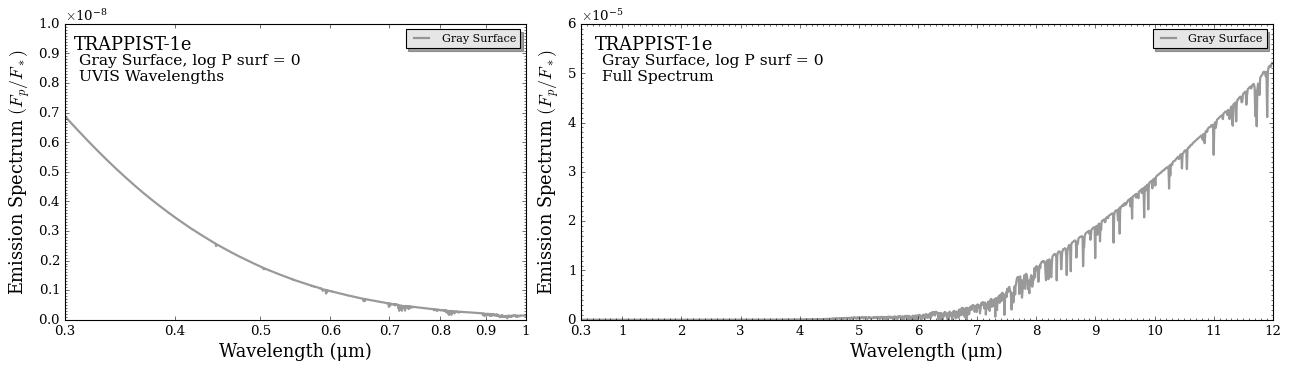

<Figure size 853.36x480 with 0 Axes>

<Figure size 853.36x480 with 0 Axes>

In [24]:
# Plot the gray surface 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Two axes, to have a zoom-in on the shorter wavelengths where reflection dominates

fig_combined = plt.figure(figsize=(16,9/2),constrained_layout=True)    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AABBB
    """
)

spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_gray_FpFs, wl, collection = spectra)

# Reflection Wavelengths only
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Gray Surface'],
                        colour_list = ['gray'], 
                        plt_label = ('Gray Surface, log P surf = 0\nUVIS Wavelengths'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_max = 1, 
                        y_max = 1e-8,
                        ax = axd['A'])  

# Full Spectrum
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Gray Surface'],
                        colour_list = ['gray'], 
                        plt_label = ('Gray Surface, log P surf = 0\nFull Spectrum'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        ax = axd['B'])  

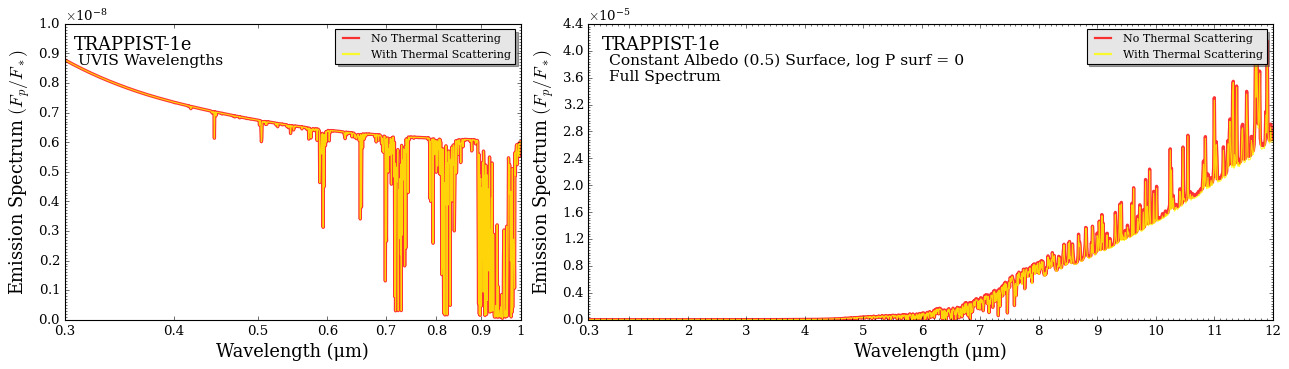

<Figure size 853.36x480 with 0 Axes>

<Figure size 853.36x480 with 0 Axes>

In [25]:
# Plot the const albedo
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Two axes, to have a zoom-in on the shorter wavelengths where reflection dominates

fig_combined = plt.figure(figsize=(16,9/2),constrained_layout=True)    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AABBB
    """
)

spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_const_no_scattering_FpFs, wl, collection = spectra)
spectra = plot_collection(spectrum_const_w_scattering_FpFs, wl, collection = spectra)

# Reflection Wavelengths only
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['No Thermal Scattering', 'With Thermal Scattering'],
                        colour_list = ['red','yellow'], 
                        plt_label = ('UVIS Wavelengths'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_max = 1, 
                        y_max = 1e-8,
                        line_width_list = [3,1],
                        ax = axd['A'])  

# Full Spectrum
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['No Thermal Scattering', 'With Thermal Scattering'],
                        colour_list = ['red','yellow'], 
                        plt_label = ('Constant Albedo (0.5) Surface, log P surf = 0\nFull Spectrum'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        line_width_list = [3,1],
                        ax = axd['B'])  

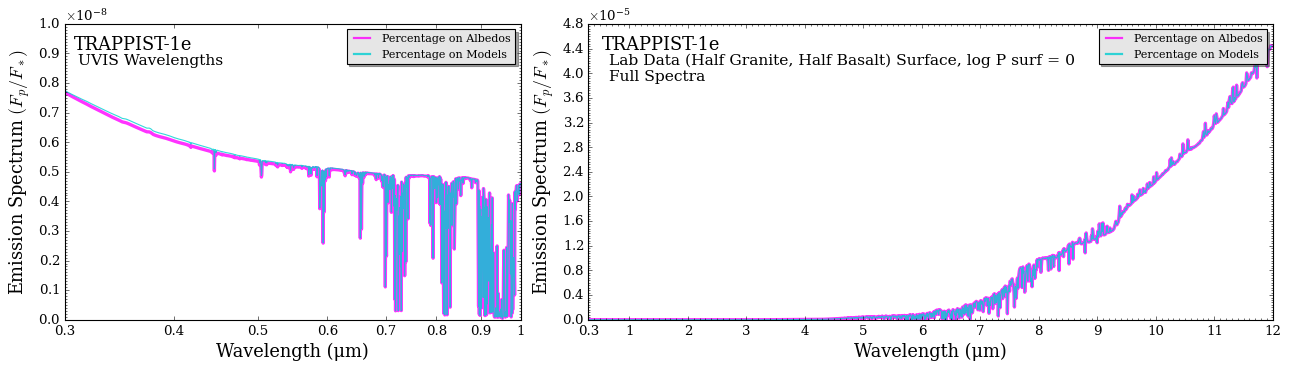

<Figure size 853.36x480 with 0 Axes>

<Figure size 853.36x480 with 0 Axes>

In [26]:
# Plot the lab data
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Two axes, to have a zoom-in on the shorter wavelengths where reflection dominates

fig_combined = plt.figure(figsize=(16,9/2),constrained_layout=True)    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AABBB
    """
)

spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_lab_data_albedos_FpFs, wl, collection = spectra)
spectra = plot_collection(spectrum_lab_data_models_FpFs, wl, collection = spectra)

# Reflection Wavelengths only
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Percentage on Albedos', 'Percentage on Models'],
                        colour_list = ['magenta','darkturquoise'], 
                        plt_label = ('UVIS Wavelengths'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_max = 1, 
                        y_max = 1e-8,
                        line_width_list = [3,1],
                        ax = axd['A'])  

# Full Spectrum
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Percentage on Albedos', 'Percentage on Models'],
                        colour_list = ['magenta','darkturquoise'], 
                        plt_label = ('Lab Data (Half Granite, Half Basalt) Surface, log P surf = 0\nFull Spectra'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        line_width_list = [3,1],
                        ax = axd['B'])  

# Adding Clouds

We can also add Mie scattering clouds to our models with surfaces. 

In particular, we can add multiple aerosols in 1D models (non-patchy clouds), or we can add up to 1 species in a patchy cloud model. (i.e., surfaces are NOT compatible with the two-sector patchy cloud featured in 'Advanced Aerosols in Eclipse Geometry' tutorial)

In this portion, we try both.

This part of the tutorial assumes familiarity with Mie scattering clouds in POSEIDON. 

In [69]:
model_name_lab_plus_clouds = 'Lab-Data-Albedo-Surface-Plus-Clouds'  

bulk_species = ['N2'] 
param_species = ['O2', 'H2O']

# List surface compoenents here 
# Names match the .txt files in 'surface_reflectivities' folder
# Lets use two common, expected rocky surfaces: basalt and granite 
surface_components = ['Tholeiitic_basalt_H25','Granitoid_H12']

# List aerosols here 
# Here we include liquid h2o and ice aerosols
aerosol_species = ['H2O_ice', 'H2O']

# Applying percentages to albedos (1 forward model generated) to speed up models
# Here, we have both aerosols be part of a single slab cloud
model_lab_h2o_one_slab = define_model(model_name_lab, bulk_species, param_species, 
                                          PT_profile = 'file_read', X_profile = 'file_read', 
                                          radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                                          reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and scattering to True
                                          cloud_model = 'Mie',cloud_type = 'one_slab',    # Slab model for both aerosol species
                                          aerosol_species = aerosol_species,              # Including aerosols
                                          surface_model = 'lab_data',              # <----- Set surface_model to 'lab_data'
                                          surface_components = surface_components, # <----- Input surface_components
                                          surface_percentage_apply_to= 'albedos',  # <----- Apply percentages to albedos
                                          surface_percentage_option = 'linear')    # <----- This is the default option (percentages, 0 to 1)

print(model_lab_h2o_one_slab['param_names'])

# Here, we do patchy clouds with just ice aerosols 
aerosol_species = ['H2O_ice']
model_lab_h2o_patchy_slab = define_model(model_name_lab, bulk_species, param_species, 
                                          PT_profile = 'file_read', X_profile = 'file_read', 
                                          radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                                          reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and scattering to True
                                          cloud_model = 'Mie',cloud_type = 'slab',    # Slab model for both aerosol species
                                          aerosol_species = aerosol_species,          # Including aerosols
                                          cloud_dim = 2,                              # Patchy Clouds
                                          surface_model = 'lab_data',              # <----- Set surface_model to 'lab_data'
                                          surface_components = surface_components, # <----- Input surface_components
                                          surface_percentage_apply_to= 'albedos',  # <----- Apply percentages to albedos
                                          surface_percentage_option = 'linear')    # <----- This is the default option (percentages, 0 to 1)

print(model_lab_h2o_patchy_slab['param_names'])

['R_p_ref' 'log_O2' 'log_H2O' 'log_P_top_slab' 'Delta_log_P'
 'log_r_m_H2O_ice' 'log_X_H2O_ice' 'log_r_m_H2O' 'log_X_H2O' 'log_P_surf'
 'Tholeiitic_basalt_H25_percentage' 'Granitoid_H12_percentage']
['R_p_ref' 'log_O2' 'log_H2O' 'f_cloud' 'log_P_top_slab_H2O_ice'
 'Delta_log_P_H2O_ice' 'log_r_m_H2O_ice' 'log_X_H2O_ice' 'log_P_surf'
 'Tholeiitic_basalt_H25_percentage' 'Granitoid_H12_percentage']


In [68]:
# Add the aerosols above to the opac object 
from POSEIDON.clouds import switch_aerosol_in_opac

opac_h2o_aerosols = switch_aerosol_in_opac(model_lab_h2o_one_slab, opac)

Reading in database for aerosol cross sections...


In [73]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem


P_ref = 1      # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure

log_P_surf = 0             # Surface pressure is 1 bar
Basalt_percentage = 0.5    # 50% basalt
Granite_percentage = 0.5   # 50% granite

surface_params = np.array([log_P_surf, 
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

log_P_top_slab = -2
Delta_log_P = 1
log_r_m_H2O = -2
log_X_H2O = -12

# Assume the same r_m and X for both H2O aerosols, for simplicity 
cloud_params = np.array([log_P_top_slab, Delta_log_P, log_r_m_H2O, log_X_H2O, log_r_m_H2O, log_X_H2O])

# Generate the atmospheres
atmosphere_lab_h2o_one_slab = make_atmosphere(planet, model_lab_h2o_one_slab, P, P_ref, R_p_ref, 
                                   T_input = T_Archean, X_input = X_Archean,
                                   cloud_params = cloud_params,
                                   surface_params = surface_params)   #<---- Put surface params into make_atmosphere 

# Lets assume 50% patchy clouds 
f_cloud = 0.5
cloud_params = np.array([f_cloud, log_P_top_slab, Delta_log_P, log_r_m_H2O, log_X_H2O])

atmosphere_lab_h2o_patchy_slab = make_atmosphere(planet, model_lab_h2o_patchy_slab, P, P_ref, R_p_ref, 
                                   T_input = T_Archean, X_input = X_Archean,
                                   cloud_params = cloud_params,
                                   surface_params = surface_params)   #<---- Put surface params into make_atmosphere 

In [74]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Compute spectra
# Remember to use new opac object here for aerosols 
spectrum_lab_h2o_one_slab_FpFs = compute_spectrum(planet, star, model_lab_h2o_one_slab, 
                                                  atmosphere_lab_h2o_one_slab, opac_h2o_aerosols, wl,
                                                  spectrum_type = 'emission', use_photosphere_radius= True)

spectrum_lab_h2o_patchy_slab_FpFs = compute_spectrum(planet, star, model_lab_h2o_patchy_slab, 
                                                  atmosphere_lab_h2o_patchy_slab, opac_h2o_aerosols, wl,
                                                  spectrum_type = 'emission', use_photosphere_radius= True)

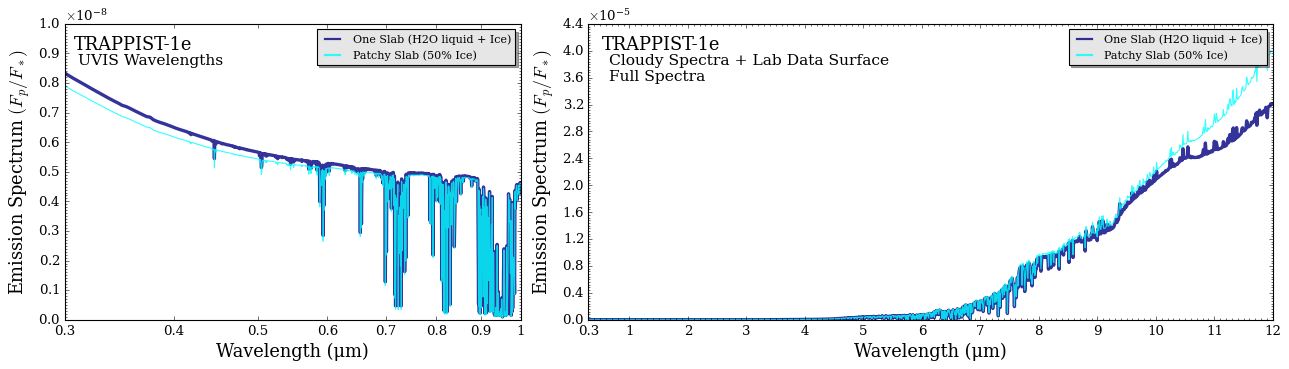

<Figure size 853.36x480 with 0 Axes>

<Figure size 853.36x480 with 0 Axes>

In [75]:
# Plot the const albedo
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Two axes, to have a zoom-in on the shorter wavelengths where reflection dominates

fig_combined = plt.figure(figsize=(16,9/2),constrained_layout=True)    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AABBB
    """
)

spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_lab_h2o_one_slab_FpFs, wl, collection = spectra)
spectra = plot_collection(spectrum_lab_h2o_patchy_slab_FpFs, wl, collection = spectra)

# Reflection Wavelengths only
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['One Slab (H2O liquid + Ice)', 'Patchy Slab (50% Ice)'],
                        colour_list = ['navy','aqua'], 
                        plt_label = ('UVIS Wavelengths'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_max = 1, 
                        y_max = 1e-8,
                        line_width_list = [3,1],
                        ax = axd['A'])  

# Full Spectrum
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['One Slab (H2O liquid + Ice)', 'Patchy Slab (50% Ice)'],
                        colour_list = ['navy','aqua'], 
                        plt_label = ('Cloudy Spectra + Lab Data Surface\nFull Spectra'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        line_width_list = [3,1],
                        ax = axd['B'])  

## Reflecting and Emitting Surfaces - Rocky Exoplanets w/ Overlaying Atmospheres (55 Cancri e)

Lets look at a hotter exoplanet with a potential magma ocean. 

In [54]:
#***** Define planet properties *****#

planet_name_55 = '55-Cancri-e'  # Planet name used for plots, output files etc.

R_p = 1.95*R_E    # Planetary radius (m)
M_p = 8.8*M_E

d = 12.5855*pc
a_p = 0.01544*au

# Create the planet object
planet_55 = create_planet(planet_name_55, R_p, mass = M_p, a_p = a_p)

#***** Define stellar properties *****#

R_s = 0.964411455860500*R_Sun      # Stellar radius (m)
T_s = 	5317.89014944000        # Stellar effective temperature (K)
Met_s = 	0.38330181143999997         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] <--- note: for PHOENIX, only the solar metallicity models are used  
log_g_s = 4.45813087040500      # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star_55 = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

#***** Specify data location and instruments *****#

model_name_55 = '55-Cancri-e'

#***** Define model *****#

bulk_species = ['CO2']
param_species = []
surface_components = ['Tholeiitic_basalt_H25']

# Create the model object
model_55 = define_model(model_name_55, bulk_species, param_species, 
                    PT_profile = 'gradient',
                    radius_unit = 'R_E', surface = True,
                    reflection = True, thermal = True, thermal_scattering = True,
                    surface_model = 'lab_data', 
                    surface_components = surface_components) 

print(model_55['param_names'])

['R_p_ref' 'T_high' 'T_deep' 'log_P_surf']


In [51]:
#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 500    # Same as prior range for T
T_fine_max = 2500    # Same as prior range for T
T_fine_step = 20     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-6   # 10 nbar
P_max = 100       # 10 bar
N_layers = 100   # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 1e-2   # Retrieved R_p_ref parameter will be the radius at 10 bar

#***** Run atmospheric retrieval *****#

    # Pre-interpolate the opacities
opac_55 = read_opacities(model_55, wl, opacity_treatment, T_fine, log_P_fine, database_version = '1.3')

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2 done
Opacity pre-interpolation complete.


In [ ]:
from POSEIDON.core import make_atmosphere

R_p_ref       =   1.92 *  R_E
T_high        =   1668
T_deep        =   2380

# Lets loop over P_surf to see the interplay between atmospheric signatures and surface signatures 

spectra = []

log_P_surf_array = [2,0,-2,-4]

for log_P_surf in log_P_surf_array:

    log_X_params = np.array([])
    PT_params = np.array( [T_high, T_deep] )
    surface_params = np.array( [log_P_surf])

    atmosphere = make_atmosphere(planet_55, model_55, P, P_ref, 
                                R_p_ref, PT_params, log_X_params = log_X_params,
                                surface_params = surface_params
                                )

    spectrum = compute_spectrum(planet_55, star_55, model_55, atmosphere, opac_55, wl,
                                    spectrum_type = 'emission')
    
    spectra = plot_collection(spectrum, wl, collection = spectra)

[2.05329393e-05 2.05318265e-05 2.05297530e-05 ... 1.05552972e-04
 1.03546577e-04 1.08637032e-04]
[8.51203508e-06 8.50349326e-06 8.48193715e-06 ... 1.05552972e-04
 1.03546577e-04 1.08637032e-04]
[2.15594528e-06 2.16130712e-06 2.16489208e-06 ... 1.05552972e-04
 1.03546577e-04 1.08637032e-04]
[2.04529767e-06 2.05057269e-06 2.05577729e-06 ... 9.42020122e-05
 9.66330447e-05 9.17412195e-05]


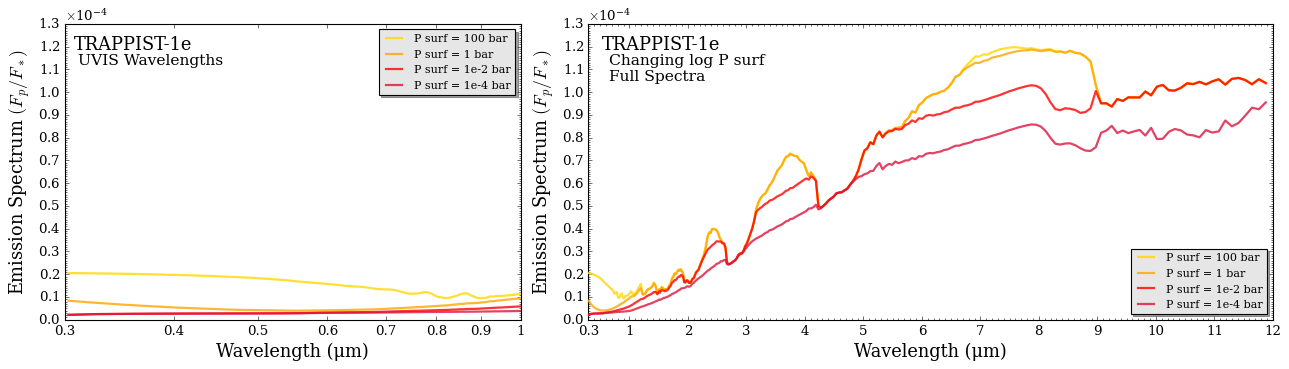

<Figure size 853.36x480 with 0 Axes>

<Figure size 853.36x480 with 0 Axes>

In [60]:
# Plot the const albedo
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Two axes, to have a zoom-in on the shorter wavelengths where reflection dominates

fig_combined = plt.figure(figsize=(16,9/2),constrained_layout=True)    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AABBB
    """
)

# Reflection Wavelengths only
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        spectra_labels = ['P surf = 100 bar', 'P surf = 1 bar', 'P surf = 1e-2 bar', 'P surf = 1e-4 bar'],
                        colour_list = ['gold','orange','red','crimson'], 
                        plt_label = ('UVIS Wavelengths'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_max = 1, 
                        ax = axd['A'])  

# Full Spectrum
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        spectra_labels = ['P surf = 100 bar', 'P surf = 1 bar', 'P surf = 1e-2 bar', 'P surf = 1e-4 bar'],
                        colour_list = ['gold','orange','red','crimson'], 
                        plt_label = ('Changing log P surf\nFull Spectra'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        legend_location = 'lower right',
                        ax = axd['B'])  

As we can see above, the basalt feature at 8.5 microns shows up in lower surface pressures (thinner atmospheres). 

# Bare Rocky Exoplanets 

Finally, lets explore exoplanets without overlaying atmospheres. 

We will specifically be exploring in this section how realstic, geological surfaces defined with lab data can have their own mid-infared features. 

### Setting a Bare Rock Model

In order to turn off the atmosphere and have a bare rocky exoplanet set surface = True, and disable_atmosphere = true in define_model(). Also, provide empty lists for the bulk and param species. 

In these models, since there is not pressure-temeprature profile to assume the surface is equilibrium with (at whatever the temperature is at P_surf), there is a new free parameter: T_surf. 

This surface temperature is assumed to be homogenous for all points on the planet's surface. 

In [28]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_gray_bare_rock = 'Gray-Surface-Bare-Rock'   

bulk_species = []                                      # For bare rocks, we have no bulk or param species
param_species = [] 

# Create a model object with a blackbody surface
model_gray_bare_rock = define_model(model_name_gray_bare_rock, bulk_species, param_species, 
                                         radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                                         reflection = True, thermal_scattering = True, thermal = True, 
                                         disable_atmosphere = True)            # <----- Set disable_atmosphere = True

print(model_gray_bare_rock['param_names'])

['R_p_ref' 'T_surf']


In [29]:
model_name_const_bare_rock = 'Constant-Albedo-Surface-Bare-Rock'  

bulk_species = []                     
param_species = [] 

model_const_bare_rock = define_model(model_name_const_bare_rock, bulk_species, param_species, 
                           radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                           reflection = True, thermal_scattering = True, thermal = True, # <----- Set reflection and scattering to True
                           surface_model = 'constant',           # <----- Set surface_model to 'constant'
                           disable_atmosphere = True)            # <----- Set disable_atmosphere = True 

print(model_const_bare_rock['param_names'])

['R_p_ref' 'T_surf' 'albedo_surf']


In [31]:
model_name_lab_bare_rock = 'Lab-Data-Albedo-Surface-Bare-Rock'  

bulk_species = []                     
param_species = [] 
surface_components = ['Tholeiitic_basalt_H25','Granitoid_H12'] # <----- List surface compoenents here 

model_lab_bare_rock = define_model(model_name_lab_bare_rock, bulk_species, param_species, 
                            radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                            reflection = True, thermal_scattering = True, thermal = True,
                            surface_model = 'lab_data',           # <----- Set surface_model to 'lab_data'
                            surface_components = surface_components,  # <----- Input surface_components
                            surface_percentage_apply_to= 'albedos',  # <----- Apply percentages to albedos
                            surface_percentage_option = 'linear',     # Default option
                            disable_atmosphere = True)                # <----- Set disable_atmosphere = True


print(model_lab_bare_rock['param_names'])

['R_p_ref' 'T_surf' 'Tholeiitic_basalt_H25_percentage'
 'Granitoid_H12_percentage']


In [35]:
from POSEIDON.core import make_atmosphere

R_p_ref = R_p  # Radius is just the planetary radius 

T_surf = 300    # Surface temperature of 300K

surface_params = np.array([T_surf]) #<---- Put surface params into new list, surface_params

P = []      #<---- No atmosphere = no pressure 
P_ref = []

atmosphere_gray_bare_rock = make_atmosphere(planet, model_gray_bare_rock, P, P_ref, R_p_ref, 
                                                 surface_params = surface_params)  #<---- Put surface params into make_atmosphere

In [33]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem

R_p_ref = R_p  

T_surf = 300          # Surface temperature of 300K
surface_albedo = 0.5  # Half reflecting, half absorbing 

surface_params = np.array([T_surf, surface_albedo,]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_const_bare_rock = make_atmosphere(planet, model_const_bare_rock, P, P_ref, R_p_ref, 
                                             surface_params = surface_params)  #<---- Put surface params into make_atmosphere   

In [ ]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem


R_p_ref = R_p  # Radius at reference pressure

T_surf = 300  # Surface temperature of 300K
Basalt_percentage = 0.5
Granite_percentage = 0.5 

surface_params = np.array([T_surf,
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_lab_bare_rock = make_atmosphere(planet, model_lab_bare_rock, P, P_ref, R_p_ref, 
                                           surface_params = surface_params)   #<---- Put surface params into make_atmosphere   

For bare rocky exoplanets, there is no opac object. 

Therefore, we define an empty opac list for compute_spectrum()

In [36]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

opac_empty = []  # No opac object when there is no atmosphere

spectrum_gray_bare_rock_FpFs = compute_spectrum(planet, star, model_gray_bare_rock, atmosphere_gray_bare_rock, 
                                                                     opac_empty, wl,
                                                                     spectrum_type = 'emission')

spectrum_const_bare_rock_FpFs = compute_spectrum(planet, star, model_const_bare_rock, atmosphere_const_bare_rock, 
                                                opac_empty, wl,
                                                spectrum_type = 'emission')

spectrum_lab_data_bare_rock_FpFs = compute_spectrum(planet, star, model_lab_bare_rock, atmosphere_lab_bare_rock, 
                                                                  opac_empty, wl,
                                                                  spectrum_type = 'emission')


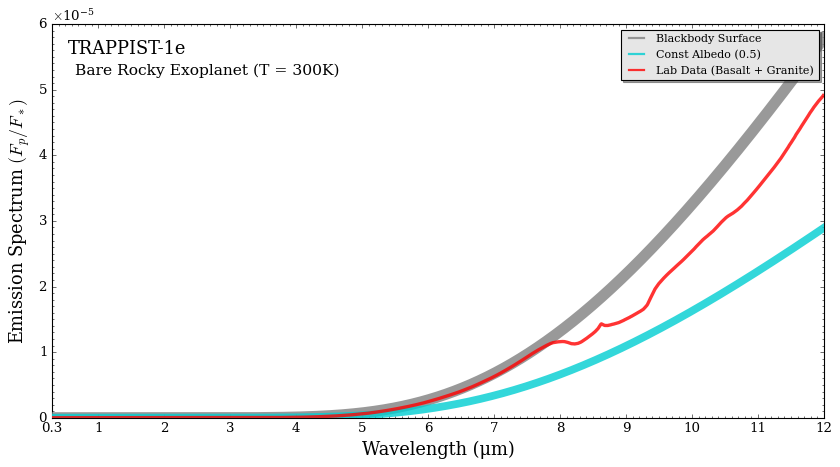

In [41]:
spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_gray_bare_rock_FpFs, wl, collection = spectra)
spectra = plot_collection(spectrum_const_bare_rock_FpFs, wl, collection = spectra)
spectra = plot_collection(spectrum_lab_data_bare_rock_FpFs, wl, collection = spectra)

# Produce figure
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Blackbody Surface','Const Albedo (0.5)', 'Lab Data (Basalt + Granite)'],
                        colour_list = ['gray','darkturquoise', 'red'], 
                        line_width_list = [10,7,3],
                        plt_label = ('Bare Rocky Exoplanet (T = 300K)'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear'
                        #y_max = 2e-14, y_min = 0
                        )  

### Surfaces Have Mid-Infrared Features

Lets explore the granite/basalt feature in the mid-infrared a bit more (and lets turn up the temperature!)

In [42]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem


R_p_ref = R_p  # Radius at reference pressure

T_surf = 1500  # Surface temperature of 300K
Basalt_percentage = 1
Granite_percentage = 0 

surface_params = np.array([T_surf,
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_basalt = make_atmosphere(planet, model_lab_bare_rock, P, P_ref, R_p_ref, 
                                           surface_params = surface_params)   #<---- Put surface params into make_atmosphere 


Basalt_percentage = 0
Granite_percentage = 1 

surface_params = np.array([T_surf,
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_granite = make_atmosphere(planet, model_lab_bare_rock, P, P_ref, R_p_ref, 
                                           surface_params = surface_params) 

Basalt_percentage = 0.5
Granite_percentage = 0.5 

surface_params = np.array([T_surf,
                           Basalt_percentage,
                           Granite_percentage]) #<---- Put surface params into new list, surface_params

# Generate the atmospheres
atmosphere_both = make_atmosphere(planet, model_lab_bare_rock, P, P_ref, R_p_ref, 
                                           surface_params = surface_params) 

In [43]:
spectrum_granite = compute_spectrum(planet, star, model_lab_bare_rock, atmosphere_granite, 
                                                                  opac_empty, wl,
                                                                  spectrum_type = 'emission')

spectrum_basalt = compute_spectrum(planet, star, model_lab_bare_rock, atmosphere_basalt, 
                                                                  opac_empty, wl,
                                                                  spectrum_type = 'emission')

spectrum_both = compute_spectrum(planet, star, model_lab_bare_rock, atmosphere_both, 
                                                                  opac_empty, wl,
                                                                  spectrum_type = 'emission')

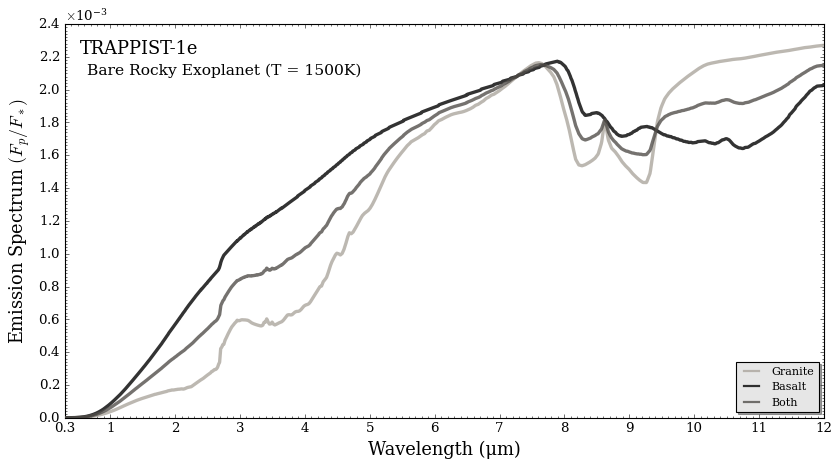

In [46]:
spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_granite, wl, collection = spectra)
spectra = plot_collection(spectrum_basalt, wl, collection = spectra)
spectra = plot_collection(spectrum_both, wl, collection = spectra)

# Produce figure
fig_spec = plot_spectra(spectra, planet, R_to_bin = 1000, plot_full_res = False,
                        spectra_labels = ['Granite','Basalt', 'Both'],
                        colour_list = ['#aca69e',"#000000", "#524f4b"], 
                        line_width_list = [3,3,3],
                        plt_label = ('Bare Rocky Exoplanet (T = 1500K)'),
                        figure_shape = 'wide',
                        y_unit = 'eclipse_depth',
                        wl_axis = 'linear',
                        legend_location = 'lower right'
                        #y_max = 2e-14, y_min = 0
                        )  

If you were able to find evidence for both granite and basalt on the surface of an exoplanet, that would be very exciting since it could indicate the prescense of a process like plate tectonics!

# Retrievals

All of the models above work with the retrieval framework in POSEIDON. 

If you are more interested in bare rocky exoplanet retrievals, see 'Retrieval Tutorial: Bare Rocky Exoplanets'